# 🩺 Diabetes Prediction Using Machine Learning

This notebook builds and evaluates Logistic Regression, Decision Tree, and Random Forest models for diabetes prediction.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, roc_auc_score
)

import joblib

print('Libraries imported successfully!')

Libraries imported successfully!


## 1. Load Dataset

In [2]:
df = pd.read_csv('Diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
print('Shape:', df.shape)
print('\nColumns:')
print(df.columns.tolist())

print('\nDataset Information:')
df.info()

print('\nStatistical Summary:')
display(df.describe())

Shape: (50, 9)

Columns:
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               50 non-null     int64  
 1   Glucose                   50 non-null     int64  
 2   BloodPressure             50 non-null     int64  
 3   SkinThickness             50 non-null     int64  
 4   Insulin                   50 non-null     int64  
 5   BMI                       50 non-null     float64
 6   DiabetesPedigreeFunction  50 non-null     float64
 7   Age                       50 non-null     int64  
 8   Outcome                   50 non-null     int64  
dtypes: float64(2), int64(7)
memory usage: 3.6 KB

Statistical Summary:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000
mean,5.280000,127.380000,70.980000,19.360000,81.540000,31.850000,0.518660,37.720000,0.500000
std,3.580218,32.597039,20.464494,16.701167,153.142619,7.930264,0.429772,11.416136,0.505076
min,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.134000,21.000000,0.000000
25%,2.000000,103.000000,66.000000,0.000000,0.000000,27.450000,0.249500,29.000000,0.000000
50%,5.000000,118.500000,73.000000,23.500000,0.000000,31.350000,0.409000,33.000000,0.500000
75%,8.000000,146.750000,83.500000,33.000000,113.750000,37.475000,0.586750,47.500000,1.000000
max,13.000000,197.000000,110.000000,47.000000,846.000000,45.800000,2.288000,60.000000,1.000000


## 2. Data Cleaning and Exploration

In [4]:
print('Missing values:')
print(df.isnull().sum())

print('\nDuplicate rows:', df.duplicated().sum())

print('\nOutcome distribution:')
print(df['Outcome'].value_counts())

Missing values:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Duplicate rows: 0

Outcome distribution:
Outcome
1    25
0    25
Name: count, dtype: int64


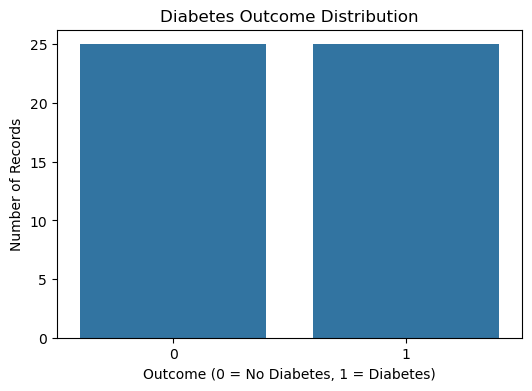

In [5]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Outcome', data=df)
plt.title('Diabetes Outcome Distribution')
plt.xlabel('Outcome (0 = No Diabetes, 1 = Diabetes)')
plt.ylabel('Number of Records')
plt.show()

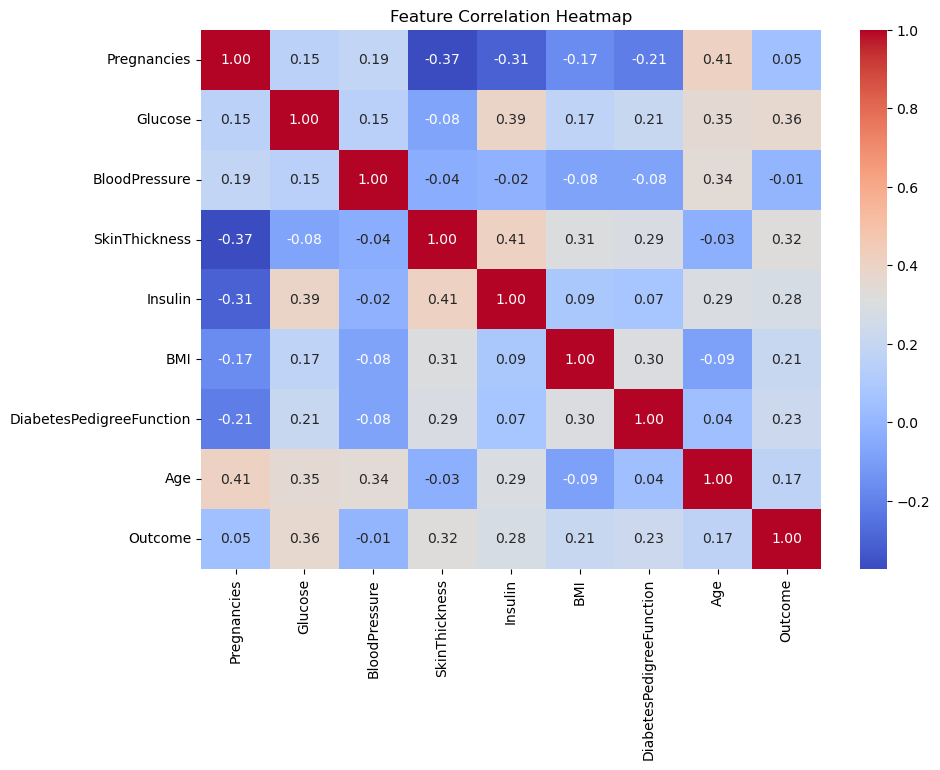

In [6]:
plt.figure(figsize=(10, 7))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.show()

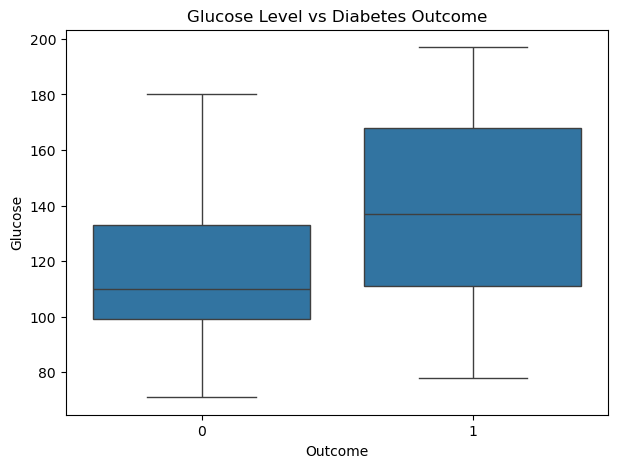

In [7]:
plt.figure(figsize=(7, 5))
sns.boxplot(x='Outcome', y='Glucose', data=df)
plt.title('Glucose Level vs Diabetes Outcome')
plt.show()

## 3. Prepare Features and Target

In [8]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print('Training data:', X_train.shape)
print('Testing data:', X_test.shape)

Training data: (40, 8)
Testing data: (10, 8)


## 4. Feature Scaling for Logistic Regression

In [9]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 5. Train Logistic Regression

In [10]:
logistic_model = LogisticRegression(max_iter=1000, random_state=42)
logistic_model.fit(X_train_scaled, y_train)

logistic_pred = logistic_model.predict(X_test_scaled)
logistic_probability = logistic_model.predict_proba(X_test_scaled)[:, 1]

print('Logistic Regression Accuracy:', accuracy_score(y_test, logistic_pred))

Logistic Regression Accuracy: 0.6


## 6. Train Decision Tree

In [11]:
decision_model = DecisionTreeClassifier(max_depth=5, random_state=42)
decision_model.fit(X_train, y_train)

decision_pred = decision_model.predict(X_test)
decision_probability = decision_model.predict_proba(X_test)[:, 1]

print('Decision Tree Accuracy:', accuracy_score(y_test, decision_pred))

Decision Tree Accuracy: 0.6


## 7. Train Random Forest

In [12]:
random_model = RandomForestClassifier(n_estimators=200, random_state=42)
random_model.fit(X_train, y_train)

random_pred = random_model.predict(X_test)
random_probability = random_model.predict_proba(X_test)[:, 1]

print('Random Forest Accuracy:', accuracy_score(y_test, random_pred))

Random Forest Accuracy: 0.4


## 8. Compare Model Performance

In [13]:
models = {
    'Logistic Regression': logistic_pred,
    'Decision Tree': decision_pred,
    'Random Forest': random_pred
}

results = []
for name, pred in models.items():
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, pred),
        'Precision': precision_score(y_test, pred, zero_division=0),
        'Recall': recall_score(y_test, pred, zero_division=0),
        'F1 Score': f1_score(y_test, pred, zero_division=0)
    })

results_df = pd.DataFrame(results)
display(results_df)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.6,0.6,0.6,0.6
1,Decision Tree,0.6,0.6,0.6,0.6
2,Random Forest,0.4,0.4,0.4,0.4


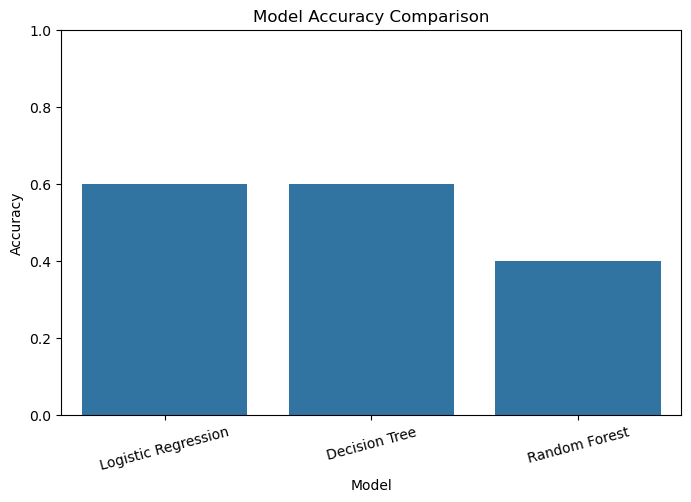

In [14]:
plt.figure(figsize=(8, 5))
sns.barplot(x='Model', y='Accuracy', data=results_df)
plt.title('Model Accuracy Comparison')
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.show()

## 9. Random Forest Classification Report

In [15]:
print(classification_report(y_test, random_pred, zero_division=0))

              precision    recall  f1-score   support

           0       0.40      0.40      0.40         5
           1       0.40      0.40      0.40         5

    accuracy                           0.40        10
   macro avg       0.40      0.40      0.40        10
weighted avg       0.40      0.40      0.40        10



## 10. Confusion Matrix

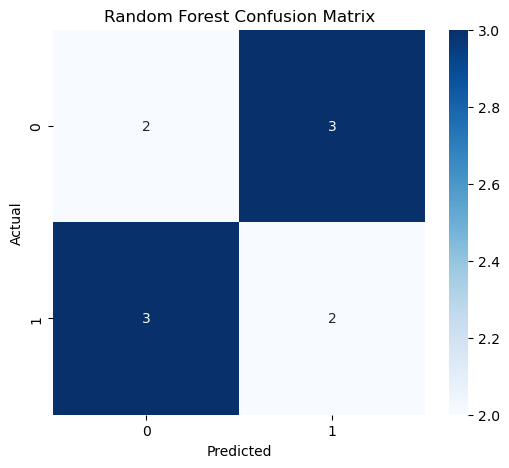

In [16]:
cm = confusion_matrix(y_test, random_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## 11. ROC Curve and AUC

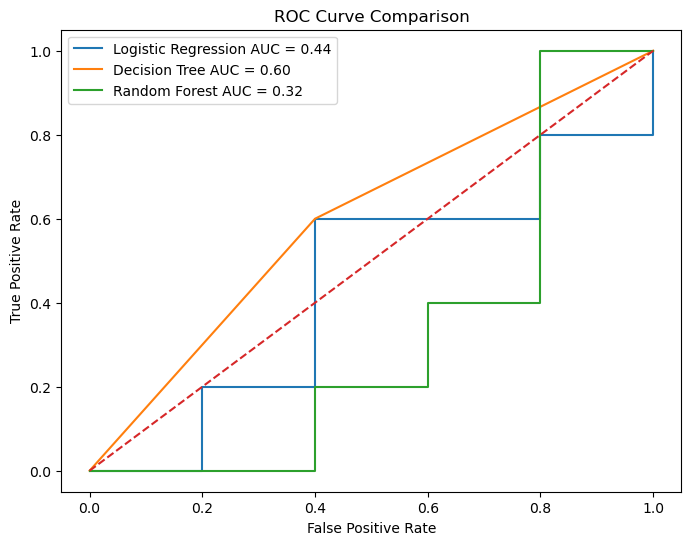

Logistic Regression AUC: 0.44
Decision Tree AUC: 0.6
Random Forest AUC: 0.32


In [17]:
logistic_fpr, logistic_tpr, _ = roc_curve(y_test, logistic_probability)
decision_fpr, decision_tpr, _ = roc_curve(y_test, decision_probability)
random_fpr, random_tpr, _ = roc_curve(y_test, random_probability)

logistic_auc = roc_auc_score(y_test, logistic_probability)
decision_auc = roc_auc_score(y_test, decision_probability)
random_auc = roc_auc_score(y_test, random_probability)

plt.figure(figsize=(8, 6))
plt.plot(logistic_fpr, logistic_tpr, label=f'Logistic Regression AUC = {logistic_auc:.2f}')
plt.plot(decision_fpr, decision_tpr, label=f'Decision Tree AUC = {decision_auc:.2f}')
plt.plot(random_fpr, random_tpr, label=f'Random Forest AUC = {random_auc:.2f}')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.show()

print('Logistic Regression AUC:', round(logistic_auc, 4))
print('Decision Tree AUC:', round(decision_auc, 4))
print('Random Forest AUC:', round(random_auc, 4))

## 12. Feature Importance

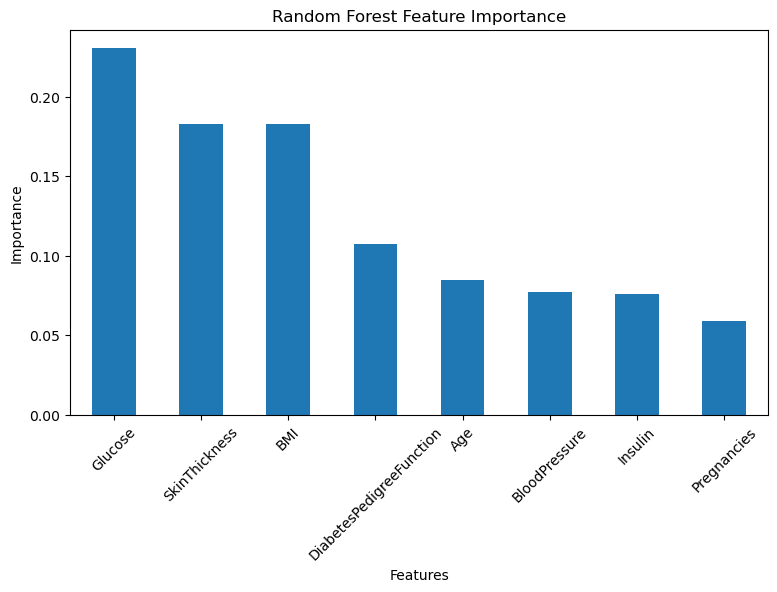

,Importance
Glucose,0.230579
SkinThickness,0.182796
BMI,0.182695
DiabetesPedigreeFunction,0.107566
Age,0.084923
BloodPressure,0.077169
Insulin,0.075533
Pregnancies,0.058738


In [18]:
importance = pd.Series(
    random_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(9, 5))
importance.plot(kind='bar')
plt.title('Random Forest Feature Importance')
plt.xlabel('Features')
plt.ylabel('Importance')
plt.xticks(rotation=45)
plt.show()

display(importance.to_frame('Importance'))

## 13. Save the Final Model

In [19]:
import os

print("Current working directory:")
print(os.getcwd())

print("\nFiles and folders:")
print(os.listdir())

Current working directory:
C:\Users\DARSH\Documents\Predictive Modeling Using Machine Learning Project

Files and folders:
['.ipynb_checkpoints', 'app.py', 'Diabetes.csv', 'Diabetes_model.pkl', 'Diabetes_Prediction.ipynb']


In [20]:
import os
import joblib

# Exact folder where you want to save the model
project_folder = r"C:\Users\DARSH\Documents\Predictive Modeling Using Machine Learning Project"

# Create the folder if it does not exist
os.makedirs(project_folder, exist_ok=True)

# Complete file path
model_path = os.path.join(
    project_folder,
    "Diabetes_model.pkl"
)

# Save Random Forest model
joblib.dump(random_model, model_path)

print("✅ Model created successfully!")
print("📍 Path:", model_path)
print("📄 File exists:", os.path.isfile(model_path))

✅ Model created successfully!
📍 Path: C:\Users\DARSH\Documents\Predictive Modeling Using Machine Learning Project\Diabetes_model.pkl
📄 File exists: True


In [21]:
# Save the trained Random Forest model
joblib.dump(random_model, '../model/Diabetes_model.pkl')
print('Model saved to ../model/Diabetes_model.pkl')

Model saved to ../model/Diabetes_model.pkl


## 14. Test a Sample Prediction

The input order must match the training features exactly.

In [22]:
sample = pd.DataFrame([{
    'Pregnancies': 2,
    'Glucose': 120,
    'BloodPressure': 70,
    'SkinThickness': 20,
    'Insulin': 80,
    'BMI': 25.0,
    'DiabetesPedigreeFunction': 0.5,
    'Age': 30
}])

sample_prediction = random_model.predict(sample)[0]
sample_probability = random_model.predict_proba(sample)[0][1]

print('Prediction:', 'Diabetes' if sample_prediction == 1 else 'No Diabetes')
print(f'Probability of Diabetes: {sample_probability:.2%}')

Prediction: No Diabetes
Probability of Diabetes: 23.00%


## Conclusion

The project demonstrates a complete supervised Machine Learning workflow including data exploration, preprocessing, model training, model comparison, confusion matrix, ROC-AUC evaluation, feature importance, and model saving. The trained model can be connected to a Streamlit application for interactive predictions.

**Note:** This project is for educational purposes and should not be used as a medical diagnostic system.